<a href="https://colab.research.google.com/github/TaruniRavipudi/RavipudiTaruni_Projects_and_Labs/blob/main/Taruni_Module4_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
X = np.array([
    [-2, 4],
    [4, 1],
    [1, 6],
    [2, 4],
    [6, 2]
])

In [3]:
X = np.array([
    [-2, 4, -1],
    [4, 1, -1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],
])

In [4]:
y = np.array([-1, -1, 1, 1, 1])

In [5]:
# Adding the bias term (-1) to each sample

X = np.array([
    [-2, 4, -1],
    [4, 1, -1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],
])

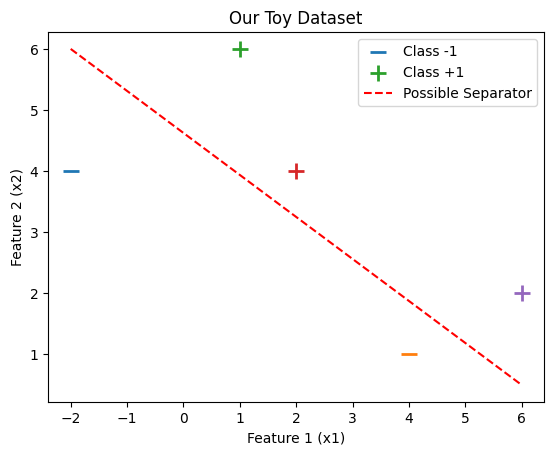

In [6]:
for d, sample in enumerate(X):
    # Plot the negative samples
    if y[d] == -1:
        plt.scatter(sample[0], sample[1], s=120, marker='_', linewidths=2, label='Class -1' if d==0 else "")
    # Plot the positive samples
    else:
        plt.scatter(sample[0], sample[1], s=120, marker='+', linewidths=2, label='Class +1' if d==2 else "")

# Add labels and a legend
plt.xlabel('Feature 1 (x1)')
plt.ylabel('Feature 2 (x2)')
plt.title('Our Toy Dataset')
plt.legend()

# For visualization, let's draw a potential separating line
# This is just a guess to show what we are looking for.
plt.plot([-2, 6], [6, 0.5], 'r--', label='Possible Separator')
plt.legend()
plt.show()

In [7]:
def perceptron_algo(X, Y):
    w = np.zeros(len(X[0]))
    eta = 1
    epochs = 10

    for epoch in range(epochs):
        for i, x in enumerate(X):
            if (np.dot(X[i], w) * Y[i]) <= 0:
                w = w + eta * X[i] * Y[i]
    return w

In [8]:
def perceptron_algo_plot(X, Y):
    '''
    train perceptron and plot the total loss in each epoch.

    :param X: data samples
    :param Y: data labels
    :return: weight vector as a numpy array
    '''
    w = np.zeros(len(X[0]))
    eta = 1
    n = 30
    errors = []

    for t in range(n):
        total_error = 0
        for i, x in enumerate(X):
            if (np.dot(X[i], w) * Y[i]) <= 0:
                total_error += (np.dot(X[i], w) * Y[i])
                w = w + eta * X[i] * Y[i]
        errors.append(total_error * -1)

    plt.plot(errors)
    plt.xlabel('Epoch')
    plt.ylabel('Total Loss')

    return w

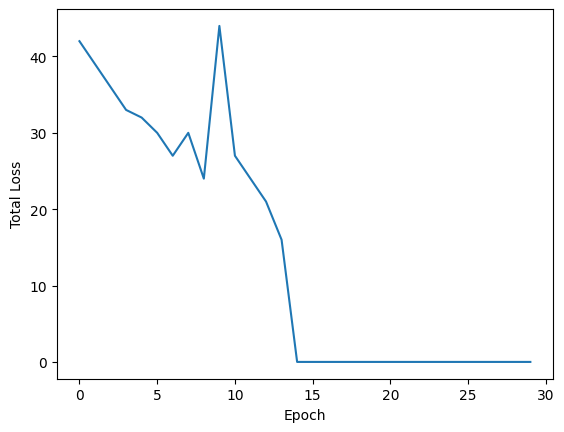

In [9]:
w = perceptron_algo_plot(X, y)

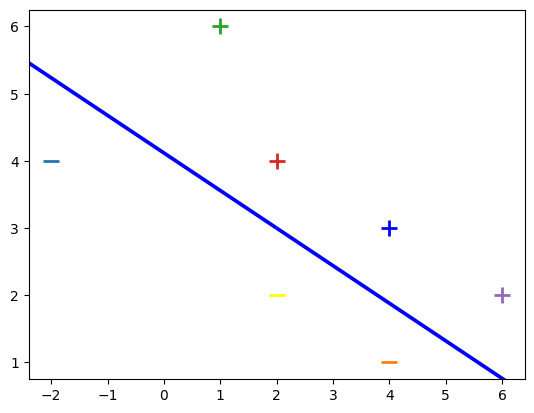

In [10]:
for d, sample in enumerate(X):
    # Plot the negative samples
    if d < 2:
        plt.scatter(sample[0], sample[1], s=120, marker='_', linewidths=2)
    # Plot the positive samples
    else:
        plt.scatter(sample[0], sample[1], s=120, marker='+', linewidths=2)

# Add our test samples

plt.scatter(2, 2, s=120, marker='_', linewidths=2, color='yellow')
plt.scatter(4, 3, s=120, marker='+', linewidths=2, color='blue')

# Print the hyperplane calculated by perceptron_sgd()
x2 = [w[0], w[1], -w[1], w[0]]
x3 = [w[0], w[1], w[1], -w[0]]

x2x3 = np.array([x2, x3])
X, Y, U, V = zip(*x2x3)
ax = plt.gca()
ax.quiver(X, Y, U, V, scale=1, color='blue')

In [11]:
from google.colab import files

uploaded = files.upload()

Saving sonar.csv to sonar.csv


In [12]:
import pandas as pd

df = pd.read_csv('sonar.csv', header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [13]:
import numpy as np

X = df.iloc[:, :-1].values

y = df.iloc[:, -1].values

y = np.where(y=='M', 1, -1)

In [14]:
bias = -1 * np.ones((X.shape[0],1))

X = np.hstack((X,bias))

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def perceptron_algo_plot(X, Y, eta=1, epochs=30):

    w = np.zeros(X.shape[1])

    errors = []

    for epoch in range(epochs):

        total_error = 0

        for i in range(len(X)):

            if (np.dot(X[i],w)*Y[i]) <= 0:

                total_error += 1

                w = w + eta*X[i]*Y[i]

        errors.append(total_error)

    plt.figure(figsize=(8,5))
    plt.plot(errors, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Misclassified Samples")
    plt.title("Perceptron Error Plot")
    plt.grid()
    plt.show()

    return w

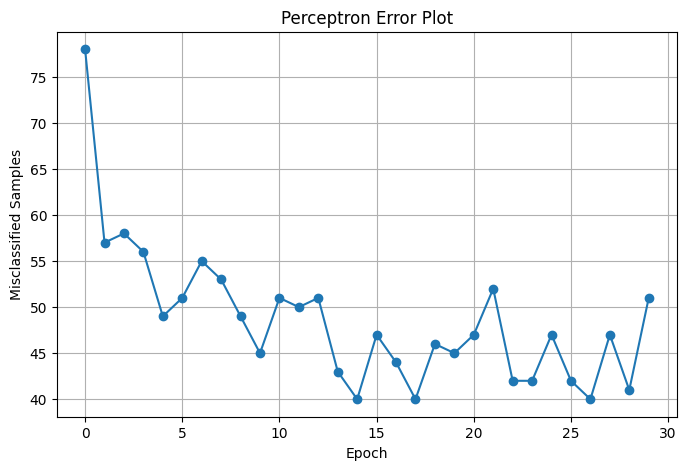

Learned Weights:
[  6.7994   5.9994  -1.8004  11.8446   8.5715  -2.1791  -7.2065  -9.4937
   5.735    3.6523  18.2702   8.7039  -2.0732  -0.1432   4.7754  -2.9881
  -3.2786   0.2909   2.9212   6.4322   1.6975  -2.418    2.753   14.3221
  -1.9797  -6.4863   4.2889   2.4475  -1.1977   7.1274 -11.1731   8.2079
   6.8195  -8.0931   2.8082  -5.3661 -10.6363  -4.8435   6.3517  -8.3264
   0.9941   0.683   10.8244  12.9621  16.6828   4.6879   3.3289  10.111
   8.5203  -0.1258   2.9383   1.7554   0.6868   1.4892   0.2455   0.5441
  -0.1874   1.6476   2.2456   1.0474  17.    ]


In [17]:
w = perceptron_algo_plot(
    X_train,
    y_train,
    eta=1,
    epochs=30
)

print("Learned Weights:")
print(w)

In [18]:
def predict(X,w):
    return np.sign(np.dot(X,w))

y_pred = predict(X_test,w)

accuracy = np.mean(y_pred == y_test)

print("Accuracy =", accuracy*100,"%")

Accuracy = 78.57142857142857 %


Learning Rate = 0.01


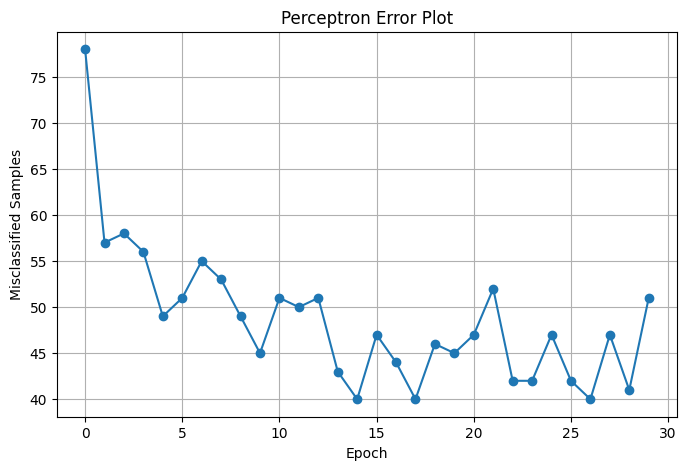

Learning Rate = 0.1


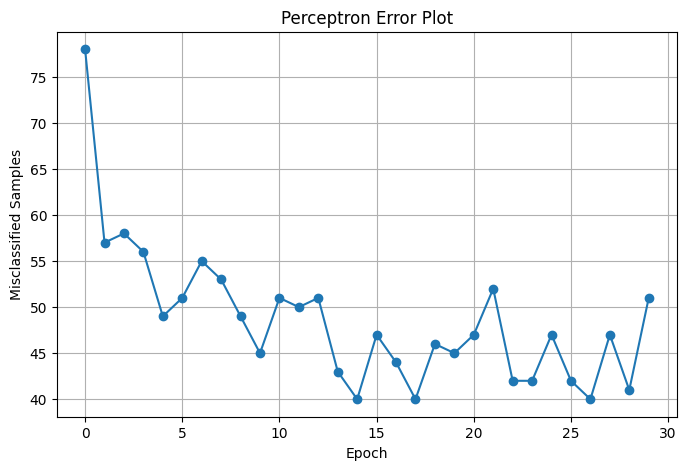

Learning Rate = 1


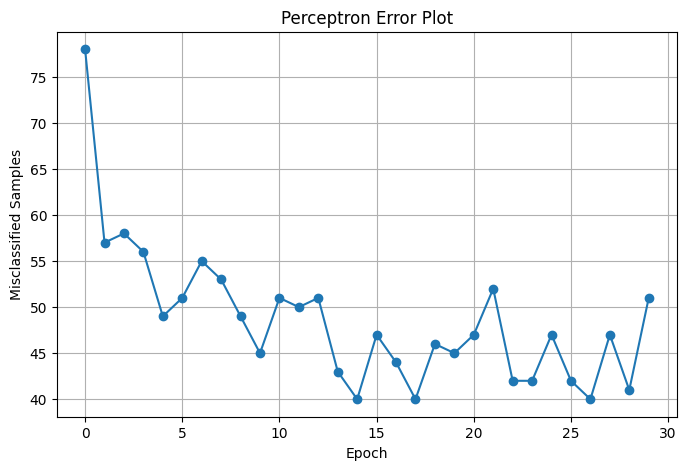

Learning Rate = 5


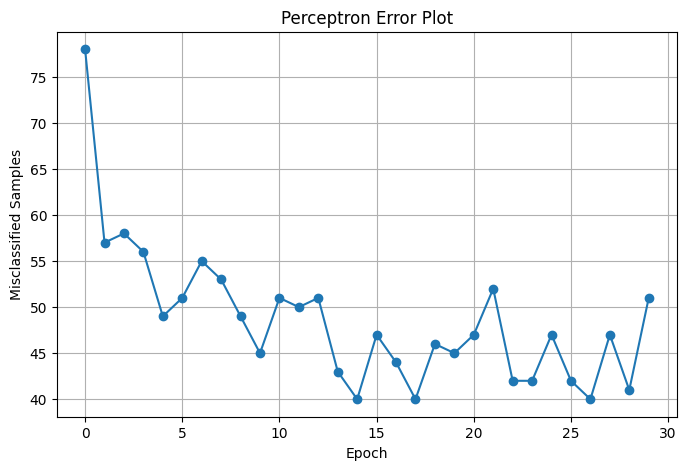

Learning Rate = 10


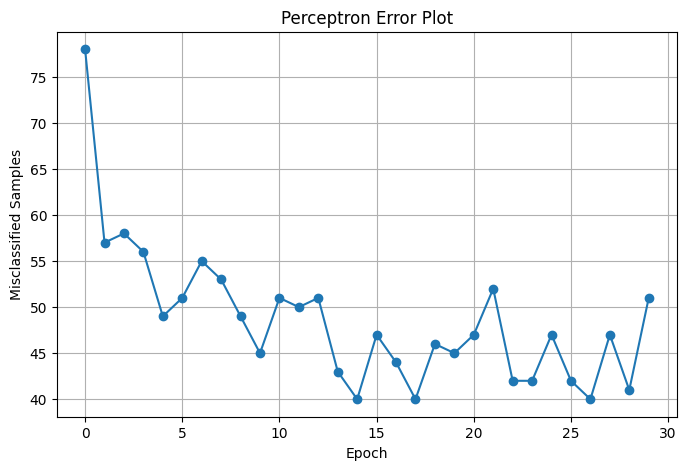

In [20]:
# Learning rate comparison
rates = [0.01,0.1,1,5,10]

for lr in rates:

    print("Learning Rate =", lr)

    perceptron_algo_plot(
        X_train,
        y_train,
        eta=lr,
        epochs=30
    )

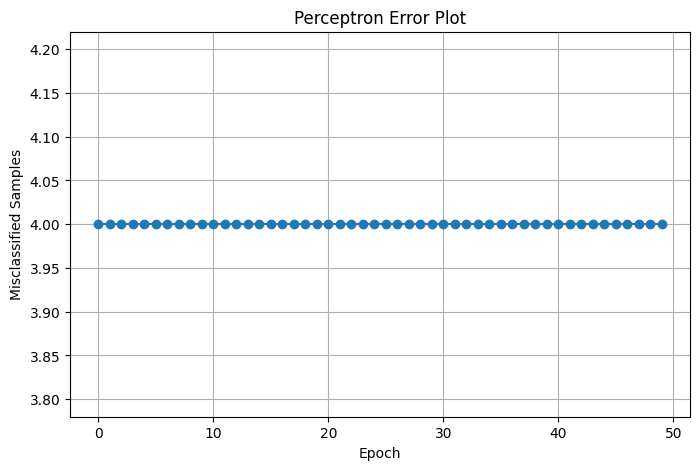

In [21]:
# Non-Linearly Separable Dataset
X = np.array([
    [0,0,-1],
    [0,1,-1],
    [1,0,-1],
    [1,1,-1]
])

y = np.array([-1,1,1,-1])

w = perceptron_algo_plot(
    X,
    y,
    eta=1,
    epochs=50
)

In [22]:
X = np.array([
    [-2, 4, -1],
    [4, 1, -1],
    [1, 6, -1],
    [2, 4, -1],
    [6, 2, -1],
])

In [23]:
y = np.array([-1, -1, 1, -1, -1]) # Note that the 4th sample's label is now -1, making the data non-linearly separable.

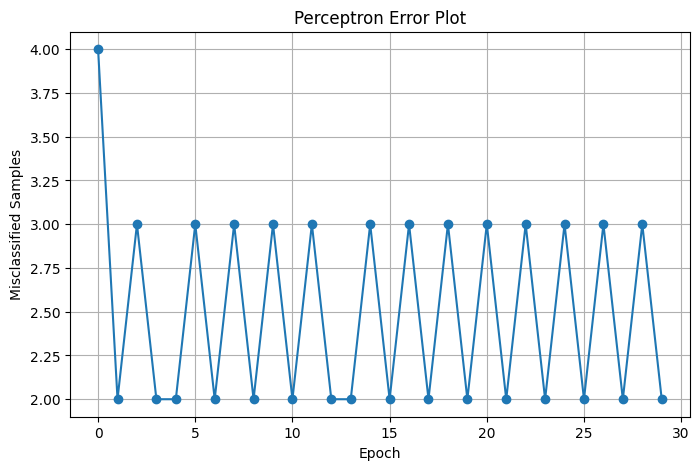

[-2.  3. 15.]


In [24]:
print(perceptron_algo_plot(X, y))